# SoundStream Neural Codec Demo



SoundStream replica demo: load a trained neural audio codec, prepare an audio sample, reconstruct it, and inspect the encoded representation.


## Setup

The setup cell resolves the project root, configures local plotting cache, and makes repository modules importable.


In [1]:
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/Ulorew/NeuralCodec.git
    %cd NeuralCodec

In [2]:
import os
from pathlib import Path
import sys
from src.utils.io_utils import ROOT_PATH, DEMO_DATA_DIR

os.environ.setdefault("MPLCONFIGDIR", str(ROOT_PATH / ".cache" / "matplotlib"))
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))


In [3]:
%pip install -r "{ROOT_PATH}/requirements.txt"

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


> Runtime note: default dependencies target CPU PyTorch; install torch-cuda for your system configuration manually to increase inference speed.


In [4]:
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn.functional as F
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from IPython.display import Audio, display

from src.transforms import Normalize1D
from src.utils.download import resolve_input
from prepare_demo import prepare_demo




## 1. Select Inputs

The demo accepts local paths or HTTP(S) URLs for the checkpoint and audio sample. Clip controls can limit the evaluated audio segment.


In [5]:
MODEL_SOURCE = "https://huggingface.co/buckets/ulorew/NeuralCodec/resolve/model.pth?download=true"
AUDIO_SOURCE = "https://huggingface.co/buckets/ulorew/NeuralCodec/resolve/helloeveryone%E2%80%8B.flac?download=true"

TARGET_SR = 16_000
CLIP_SECONDS = None
START_SECONDS = 0.0

In [6]:
def select_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    return torch.device("cuda")


def display_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT_PATH))
    except ValueError:
        return str(path)


def load_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state_dict = checkpoint.get("state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    model.load_state_dict(state_dict)
    return checkpoint


Prepare model and audio files by downloading them or selecting your local ones.

In [7]:
model_path, audio_path = prepare_demo(model_source=MODEL_SOURCE, audio_source=AUDIO_SOURCE)

Resolving files... It might take a few minutes.
Done.


## 2. Load Model

The model architecture comes from `src/configs/model/soundstream.yaml`; the checkpoint provides trained weights.


In [8]:
device = select_device()

config_dir = str((ROOT_PATH / "src/configs").resolve())
with initialize_config_dir(version_base=None, config_dir=config_dir):
    cfg = compose(config_name="inference")

model = instantiate(cfg.model).to(device)
checkpoint = load_checkpoint(model, model_path, device)
model.eval()

epoch = checkpoint.get("epoch", "unknown") if isinstance(checkpoint, dict) else "raw state_dict"
print(f"Loaded checkpoint: {display_path(model_path)}  \nEpoch: {epoch}  \nDevice: {device}")


Loaded checkpoint: demo_data/model.pth  
Epoch: 199  
Device: cpu


## 3. Prepare Audio

The codec expects mono 16 kHz audio. The preparation step converts channels, resamples, selects the requested segment, aligns the length to the model stride, and applies peak normalization.


In [9]:

def load_audio(path, target_sr=TARGET_SR):
    wave, sr = torchaudio.load(str(path))
    if wave.shape[0] > 1:
        wave = wave.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wave = torchaudio.transforms.Resample(sr, target_sr)(wave)
    return wave, target_sr


def prepare_audio(wave, sr, clip_seconds=CLIP_SECONDS, start_seconds=START_SECONDS, factor=200):
    target_len = int(round(clip_seconds * sr)) if clip_seconds else wave.shape[-1]

    start = int(round(start_seconds * sr))
    stop = start + target_len
    clip = wave[..., start:stop]
    if clip.shape[-1] < target_len:
        clip = F.pad(clip, (0, target_len - clip.shape[-1]))

    usable_len = clip.shape[-1] - (clip.shape[-1] % factor)
    clip = clip[..., :usable_len]

    batch = Normalize1D()(clip.unsqueeze(0).clone())
    return batch


raw_wave, sample_rate = load_audio(audio_path)
orig = prepare_audio(raw_wave, sample_rate).to(device)

duration = orig.shape[-1] / sample_rate
peak = orig.abs().max().item()

print(
    f"Loaded audio: {display_path(audio_path)}  \nPrepared shape: {tuple(orig.shape)}  \nDuration: {duration:.2f}s  \nPeak after normalization: {peak:.3f}"
)


Loaded audio: demo_data/helloeveryone​.flac  
Prepared shape: (1, 1, 122800)  
Duration: 7.67s  
Peak after normalization: 1.000


## 4. Run Codec Inference

A forward pass returns reconstructed waveform samples and RVQ code indices. The separate encode/decode path below exposes the same codec interface directly.


In [10]:
with torch.no_grad():
    out = model(orig=orig)

recon = out["recon"].detach().cpu().clamp(-1, 1)
orig_cpu = orig.detach().cpu().clamp(-1, 1)
codes = out["codes"]
codes_cpu = codes.detach().cpu()

bits_per_code = int(torch.ceil(torch.log2(torch.tensor(cfg.model.cb_size))).item())
kbps = codes_cpu.numel() * bits_per_code / 1000 / duration

print(
    f"Codes: {tuple(codes_cpu.shape)}  \nEstimated bitrate: {kbps:.2f} kbps  \nMean codebook perplexity: {out['mean_perplexity'].item():.2f}")


Codes: (1, 614, 8)  
Estimated bitrate: 6.40 kbps  
Mean codebook perplexity: 337.53


## 5. Listen

In [11]:
print("Original")
display(Audio(orig_cpu[0, 0], rate=sample_rate))

print("Reconstruction")
display(Audio(recon[0, 0], rate=sample_rate))


Original


Reconstruction


## 6. Quick Visual Check

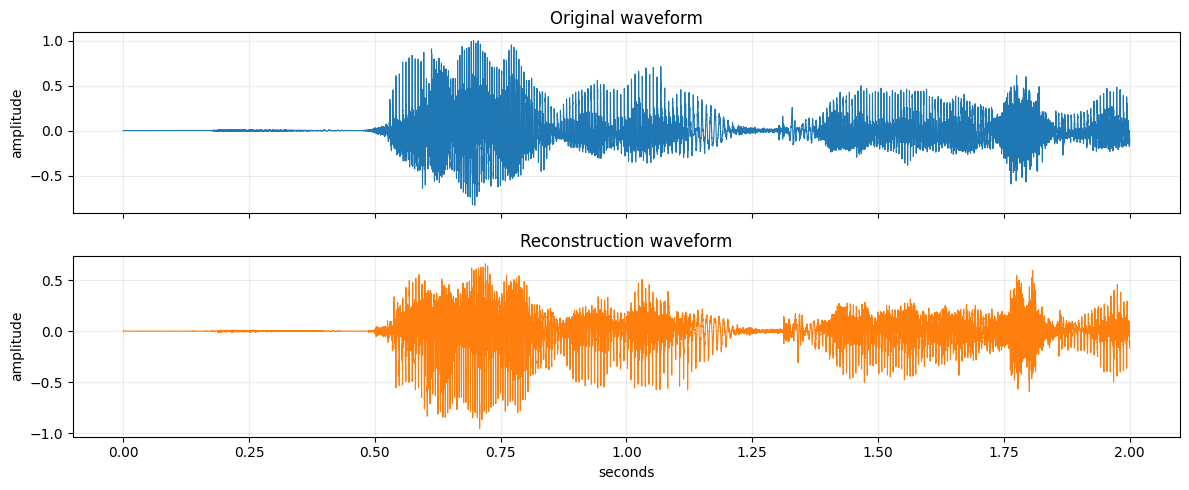

In [12]:
seconds = torch.arange(orig_cpu.shape[-1]) / sample_rate
preview = min(orig_cpu.shape[-1], sample_rate * 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(seconds[:preview], orig_cpu[0, 0, :preview], linewidth=0.8)
axes[0].set_title("Original waveform")
axes[0].set_ylabel("amplitude")
axes[1].plot(seconds[:preview], recon[0, 0, :preview], linewidth=0.8, color="tab:orange")
axes[1].set_title("Reconstruction waveform")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("amplitude")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Save Demo Output

In [13]:
output_flac = DEMO_DATA_DIR / "reconstruction.flac"
torchaudio.save(str(output_flac), recon[0], sample_rate)

print(f"Saved reconstruction to {display_path(output_flac)}")

Saved reconstruction to demo_data/reconstruction.flac


## 8. Encode and Decode Separately

`model.gen` exposes the generator-only codec. Its `encode` method produces RVQ codes, and `decode` reconstructs audio from those codes.


In [14]:
gen = model.gen
with torch.no_grad():
    out = gen.encode(orig=orig)

codes = out["codes"]
codes_cpu = codes.detach().cpu()

print(f"Codes: {tuple(codes_cpu.shape)}\n")

Codes: (1, 614, 8)



The code tensor is the compact representation that can be stored or transmitted before decoding.


In [15]:
with torch.no_grad():
    out = gen.decode(codes)
recon_sep = out["recon"].detach().cpu().clamp(-1, 1)
print("Reconstruction")
display(Audio(recon_sep[0, 0], rate=sample_rate))

Reconstruction


Compare the direct reconstruction with the reconstruction produced by separate encode/decode calls.


In [16]:
mean_rel_err = ((recon - recon_sep) / recon_sep.abs().clamp_min(1e-8)).abs().mean()
mean_abs_err = (recon - recon_sep).abs().mean()
close = torch.allclose(recon, recon_sep)

print(f"MAE between direct forward and separate calls is {mean_abs_err:.1e}.")
print(f"MRE between direct forward and separate calls is {mean_rel_err:.1e}.")

print(f"Files are {"similar" if close else "not similar"}.")

MAE between direct forward and separate calls is 2.4e-08.
MRE between direct forward and separate calls is 6.4e-05.
Files are not similar.


There is some difference in computation scheme of forward call due to optimization, so there might be small numerical difference.